# From Linear Regression in NumPy to Logistic Regression in PyTorch

## Goals

- Compare implementing regression in NumPy vs PyTorch
- Extend regression to classification by adding softmax and cross-entropy
- Practice working with PyTorch's basic APIs

## Setup

Let's import necessary modules: *pandas* and NumPy for data wrangling, Matplotlib for plotting, and some sklearn utilities. We'll be implementing the linear regression model ourselves, so we don't need to import it from sklearn.

In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
import scipy.optimize

We'll load the data as before.

In [ ]:
ames = pd.read_csv('https://github.com/kcarnold/AmesHousing/blob/master/data/ames.csv.gz?raw=true', compression="gzip")
ames['price'] = ames["Sale_Price"] / 100_000 # Make `price` be in units of $100k, to be easier to interpret.

# Create price categories (0, 1, or 2) for the classification task
ames['price_rank'] = ames.price.rank(pct=True)
ames['price_bin'] = 0 + (ames.price_rank > 1/3) + (ames.price_rank > 2/3)
n_classes = 3

# Prepare features and target
feature_names = ['Longitude', 'Latitude']
X = ames[feature_names].values
y = ames['price_bin'].values

# standardize the features, to make the optimization more stable
X_mean = X.mean(axis=0)
X_std = X.std(axis=0)
X = (X - X_mean) / X_std

# Split data
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)

### Basic EDA

Histogram of target values for regression task:

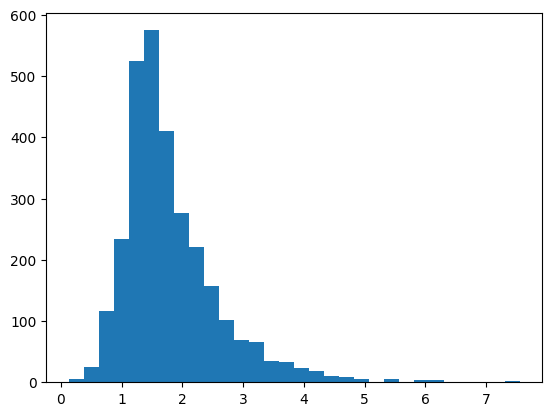

In [ ]:
plt.hist(ames['price'], bins=30);

Histogram of target values for classification task:

price_bin
0    981
1    980
2    969
Name: count, dtype: int64

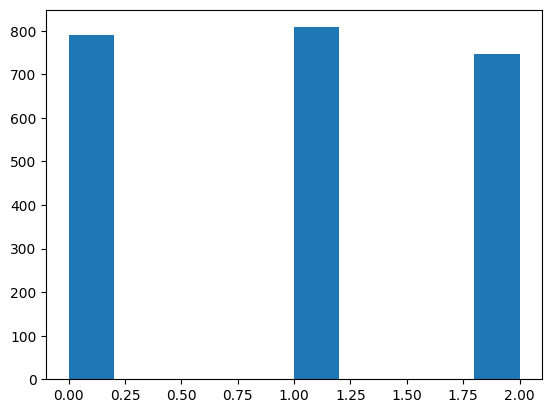

In [ ]:
plt.hist(y_train);
ames['price_bin'].value_counts()

Check shapes

In [ ]:
X_train.shape, y_train.shape

((2344, 2), (2344,))

In [ ]:
X_valid.shape, y_valid.shape

((586, 2), (586,))

Histogram of input feature values

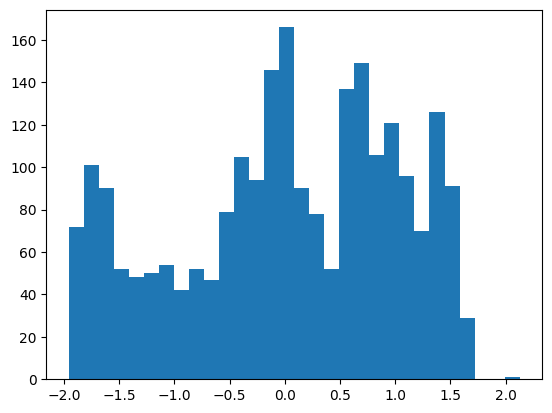

In [ ]:
plt.hist(X_train[:, 0], bins=30);

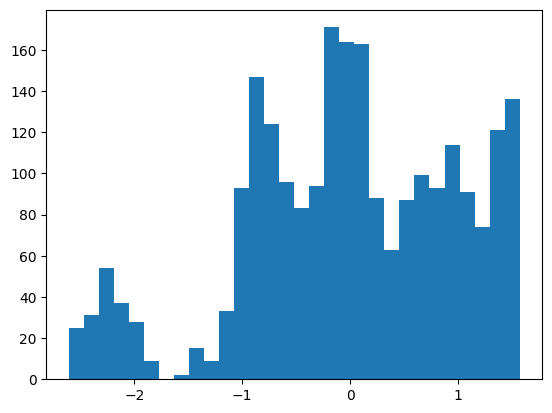

In [ ]:
plt.hist(X_train[:, 1], bins=30);

## Part 1: Classification the wrong way (with regression)

Let's start by treating this as a regression problem - predicting the class number (0, 1, or 2) directly. We'll fit a linear regression model to the target as if it were a continuous variable.

### 1.A Using NumPy

In [ ]:
# Initialize parameters
np.random.seed(42)
n_samples, n_features = X_train.shape

initial_weights = np.random.standard_normal(size=...)
initial_bias = np.random.standard_normal()

def linear_forward(X, weights, bias):
    return X @ weights + bias

def compute_mse_loss(y_true, y_pred):
    return ((y_true - y_pred) ** 2).mean()

def unpack_params(params):
    weights = params[:-1].reshape(initial_weights.shape)
    bias = params[-1]
    return weights, bias

def pack_params(weights, bias):
    return np.concatenate([weights, [bias]])

def loss_given_params(params, X, y_true):
    weights, bias = unpack_params(params)
    y_pred = linear_forward(X, weights, bias)
    return compute_mse_loss(...)

initial_params = pack_params(initial_weights, initial_bias)
initial_loss = loss_given_params(initial_params, X_train, y_train)
optimization_result = scipy.optimize.minimize(loss_given_params, initial_params,
                                              args=(X_train, y_train))
fitted_weights_np, fitted_bias_np = unpack_params(optimization_result.x)
print(f"Initial loss: {initial_loss:.2f}")
print(f"Final loss: {optimization_result.fun:.2f}")
print(f"Fitted weights: {fitted_weights_np}")
print(f"Fitted bias: {fitted_bias_np}")

Initial loss: 1.33
Final loss: 0.56
Fitted weights: [-0.26364467  0.17475395]
Fitted bias: 0.9886359257077487


Let's evaluate the "accuracy" of this model. We'll round the predictions to the nearest integer to get the predicted class.

In [ ]:
y_pred_valid = linear_forward(X_valid, fitted_weights_np, fitted_bias_np).round()
y_pred_valid

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 1., 1., 1., 1.,
       1., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 0., 1., 1., 1., 0.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 0., 1., 1., 1., 1., 1., 0., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 2., 1., 1., 1.,
       1., 1., 1., 0., 0.

In [ ]:
accuracy = (y_pred_valid == y_valid).mean()
print(f"Validation accuracy for linear regression 'classifier': {accuracy:.2f}")

Validation accuracy for linear regression 'classifier': 0.31


### 1.B: Using PyTorch

Now we'll implement the same (wrong) model in PyTorch.

We'll build this together step by step. Notice that we're still doing this "the wrong way", as regression, not classification.

In [ ]:
# Convert data to PyTorch tensors
X_train_torch = torch.tensor(X_train, dtype=torch.float32)
X_valid_torch = torch.tensor(X_valid, dtype=torch.float32)
# Note: still treating as regression
y_train_torch = torch.tensor(y_train, dtype=torch.float32)
y_valid_torch = torch.tensor(y_valid, dtype=torch.float32)

# Let's start with just learning bias terms
class SimpleLinear(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        self.bias = nn.Parameter(torch.zeros(1))
    
    def forward(self, x):
        return self.bias.expand(len(x))

# TODO (together): Add weights to make it a proper linear model

# Training loop (we'll talk next week about how this works)
model = SimpleLinear(n_features)
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)
loss_fn = nn.MSELoss()

n_epochs = 100
for epoch in range(n_epochs):
    # Forward pass
    y_pred = model(X_train_torch)
    loss = loss_fn(y_pred, y_train_torch)
    
    # Backward pass
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    if epoch % 10 == 0:
        print(f'Epoch {epoch:02d}, Loss: {loss.item():.4f}')

Epoch 00, Loss: 1.6177
Epoch 10, Loss: 0.6660
Epoch 20, Loss: 0.6551
Epoch 30, Loss: 0.6549
Epoch 40, Loss: 0.6549
Epoch 50, Loss: 0.6549
Epoch 60, Loss: 0.6549
Epoch 70, Loss: 0.6549
Epoch 80, Loss: 0.6549
Epoch 90, Loss: 0.6549


## Part 2: Converting to Classification

### 2.A Using NumPy (we'll do this together)

Let's modify our NumPy implementation to:
1. Output one number per class (logits)
2. Convert logits to probabilities using softmax
3. Use cross-entropy loss instead of MSE

In [ ]:
y_train_onehot = np.eye(n_classes)[y_train]
y_valid_onehot = np.eye(n_classes)[y_valid]

def softmax(logits):
    """Convert logits to probabilities."""
    # We'll implement this together
    pass

def cross_entropy_loss(y_true_onehot, probs):
    """Compute cross entropy loss."""
    # We'll implement this together
    pass

In [ ]:
# copy and paste the NumPy code block here and we'll edit.
# your code here

Initial loss: 1.93
Final loss: 1.02
Fitted weights: [[ 0.7753546   0.39962183 -0.16883813]
 [ 0.01584829  0.34061106  0.69827992]]
Fitted bias: [0.61377123 0.75167041 0.51173135]


Now let's compute the accuracy again.

In [ ]:
y_pred_valid_logits = linear_forward(X_valid, fitted_weights_np, fitted_bias_np)
y_pred_valid = y_pred_valid_logits.argmax(axis=1)
y_pred_valid

array([0, 1, 2, 2, 0, 2, 0, 1, 2, 2, 1, 2, 0, 1, 0, 2, 1, 2, 0, 0, 2, 2,
       2, 2, 2, 1, 0, 2, 1, 2, 2, 0, 0, 0, 0, 0, 2, 2, 2, 1, 2, 2, 0, 0,
       1, 2, 1, 1, 2, 0, 1, 0, 2, 0, 2, 2, 2, 0, 2, 2, 0, 2, 0, 2, 2, 0,
       2, 1, 2, 2, 0, 2, 1, 0, 2, 2, 1, 2, 0, 0, 0, 1, 0, 1, 2, 0, 1, 0,
       2, 2, 2, 1, 2, 0, 2, 2, 0, 0, 2, 2, 2, 0, 2, 2, 2, 0, 2, 0, 0, 0,
       2, 1, 0, 1, 2, 2, 2, 0, 2, 2, 0, 1, 0, 0, 1, 2, 1, 2, 2, 2, 1, 2,
       1, 0, 2, 2, 1, 0, 0, 2, 0, 2, 0, 2, 0, 0, 0, 2, 2, 1, 2, 2, 0, 0,
       0, 0, 1, 0, 1, 0, 2, 1, 2, 2, 0, 2, 2, 2, 2, 2, 0, 0, 2, 2, 0, 1,
       0, 0, 0, 2, 2, 2, 2, 0, 0, 1, 0, 2, 2, 2, 2, 2, 0, 0, 0, 1, 0, 1,
       2, 0, 0, 2, 2, 2, 2, 2, 0, 2, 0, 0, 1, 0, 2, 0, 2, 0, 2, 2, 1, 2,
       1, 2, 2, 2, 0, 0, 2, 2, 2, 2, 2, 2, 2, 1, 0, 2, 2, 1, 0, 2, 0, 2,
       2, 0, 2, 2, 0, 2, 2, 0, 1, 0, 2, 0, 2, 0, 0, 2, 2, 0, 0, 2, 2, 0,
       2, 0, 2, 2, 0, 0, 2, 1, 0, 2, 0, 0, 2, 0, 0, 2, 2, 2, 2, 2, 1, 2,
       0, 1, 1, 2, 0, 1, 2, 0, 1, 1, 2, 2, 2, 1, 2,

In [ ]:
accuracy = (y_pred_valid == y_valid).mean()
print(f"Validation accuracy for logistic regression: {accuracy:.2f}")

Validation accuracy for logistic regression: 0.52


### 2.B Using PyTorch

We'll first walk through the PyTorch primitives together, then you'll modify the PyTorch code from Part 1 to use these primitives.

In [ ]:
y_train_longtensor = torch.tensor(y_train)
y_valid_longtensor = torch.tensor(y_valid)

#### Setting up the linear layer

Fill in the blanks below with the correct number of features.

In [ ]:
linear_layer = nn.Linear(in_features=..., out_features=..., bias=True)
logits = linear_layer(X_train_torch)
logits.shape

torch.Size([2344, 3])

#### Softmax

PyTorch has builtin functionality for softmax. We can use it like this:

In [ ]:
probs = logits.softmax(axis=1)
probs.shape

torch.Size([2344, 3])

Let's check that the probabilities sum to 1 for each row. Think about what axis you should use for the sum. *General sum rule: whatever axis we sum over will be the axis that disappears.*

In [ ]:
probs_sums = probs.sum(axis=...)
probs_sums.shape

torch.Size([2344])

In [ ]:
probs_sums[:10]

tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000], grad_fn=<SliceBackward0>)

#### Cross-entropy loss

There are a few different ways we could implement a categorical cross-entropy loss in PyTorch; notice that they all give the same output. The `F.cross_entropy` approach is most efficient and numerically stable (because it avoids having to exponentiate the logits).

In [ ]:
y_train_onehot_torch = torch.tensor(y_train_onehot, dtype=torch.int64) # see also F.one_hot if you're curious.
log_probs = probs.log()
-(y_train_onehot_torch * log_probs).sum(axis=1).mean()

tensor(1.1288, grad_fn=<NegBackward0>)

In [ ]:
F.nll_loss(log_probs, y_train_longtensor)

tensor(1.1288, grad_fn=<NllLossBackward0>)

In [ ]:
F.nll_loss(logits.log_softmax(axis=1), y_train_longtensor)

tensor(1.1288, grad_fn=<NllLossBackward0>)

In [ ]:
F.cross_entropy(logits, y_train_longtensor)

tensor(1.1288, grad_fn=<NllLossBackward0>)

Torch has both "object-oriented" and "functional" interfaces for most operations. For example, we could also write the above as:

In [ ]:
loss_fn = nn.CrossEntropyLoss()
loss_fn(logits, y_train_longtensor)

tensor(1.1288, grad_fn=<NllLossBackward0>)

#### Full PyTorch Implementation

In [ ]:
# copy and paste your PyTorch linear regression code here and modify it to use softmax and cross-entropy loss
# your code here

Epoch 00, Loss: 1.1109
Epoch 10, Loss: 1.0690
Epoch 20, Loss: 1.0470
Epoch 30, Loss: 1.0349
Epoch 40, Loss: 1.0280
Epoch 50, Loss: 1.0238
Epoch 60, Loss: 1.0212
Epoch 70, Loss: 1.0195
Epoch 80, Loss: 1.0184
Epoch 90, Loss: 1.0177


### Looking ahead: a multi-layer network

Just as a preview for where we're going next week:

In [ ]:
n_hidden = 100
model = nn.Sequential(
    nn.Linear(in_features=n_features, out_features=n_hidden, bias=True),
    nn.ReLU(),
    nn.Linear(in_features=n_hidden, out_features=n_classes, bias=True),
)

optimizer = torch.optim.SGD(model.parameters(), lr=0.1)
loss_fn = nn.CrossEntropyLoss()

n_epochs = 1000
for epoch in range(n_epochs):
    # Forward pass
    logits = model(X_train_torch)
    loss = loss_fn(logits, y_train_longtensor)
    
    # Backward pass
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    if epoch % 10 == 0:
        print(f'Epoch {epoch:03d}, Loss: {loss.item():.4f}')

# Evaluate on validation set
logits_valid = model(X_valid_torch)
y_pred_valid = logits_valid.argmax(dim=1)
accuracy = (y_pred_valid == y_valid_longtensor).float().mean()
print(f'Validation accuracy: {accuracy.item():.2f}')

Epoch 000, Loss: 1.0690
Epoch 010, Loss: 0.9982
Epoch 020, Loss: 0.9789
Epoch 030, Loss: 0.9657
Epoch 040, Loss: 0.9547
Epoch 050, Loss: 0.9451
Epoch 060, Loss: 0.9367
Epoch 070, Loss: 0.9293
Epoch 080, Loss: 0.9227
Epoch 090, Loss: 0.9170
Epoch 100, Loss: 0.9119
Epoch 110, Loss: 0.9074
Epoch 120, Loss: 0.9034
Epoch 130, Loss: 0.8998
Epoch 140, Loss: 0.8967
Epoch 150, Loss: 0.8938
Epoch 160, Loss: 0.8913
Epoch 170, Loss: 0.8890
Epoch 180, Loss: 0.8869
Epoch 190, Loss: 0.8850
Epoch 200, Loss: 0.8832
Epoch 210, Loss: 0.8816
Epoch 220, Loss: 0.8801
Epoch 230, Loss: 0.8786
Epoch 240, Loss: 0.8773
Epoch 250, Loss: 0.8760
Epoch 260, Loss: 0.8748
Epoch 270, Loss: 0.8736
Epoch 280, Loss: 0.8725
Epoch 290, Loss: 0.8714
Epoch 300, Loss: 0.8704
Epoch 310, Loss: 0.8694
Epoch 320, Loss: 0.8684
Epoch 330, Loss: 0.8675
Epoch 340, Loss: 0.8666
Epoch 350, Loss: 0.8657
Epoch 360, Loss: 0.8649
Epoch 370, Loss: 0.8641
Epoch 380, Loss: 0.8633
Epoch 390, Loss: 0.8625
Epoch 400, Loss: 0.8617
Epoch 410, Loss:

## Analysis

Come back to these questions after you've finished the lab.

1. Compare the NumPy and PyTorch implementations. What are the main differences you notice? What are the benefits of PyTorch?

2. We came up with 4 weight matrices in the main part of this exercise (linear regression NumPy and PyTorch, logistic regression NumPy and PyTorch). Which of these matrices had the same shapes? Which ones had the same values? Why?

3. Which of these two models (linear regression vs logistic regression) does better on this task? (Which number would we use to compare them: loss, accuracy, or something else? Why?)

4. Suppose a job interviewer asks you to describe the similarities and differences between linear regression and logistic regression. What would you say? (Hint: discuss how each model makes a prediction, what kinds of patterns in the data they can use, how you measure training progress, etc.

*your thoughtful answers here*